# GNN-3: Molecular Property Prediction — Exploratory Analysis

This notebook contains:
1. Dataset exploration (QM9 statistics, graph size distributions)
2. Feature inspection (atom / bond type distributions)
3. Baseline sanity checks (mean predictor)
4. Quick visualization of results after training

In [2]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.datasets import QM9

plt.rcParams.update({'figure.dpi': 120, 'font.size': 12})

## 1. Load QM9

In [3]:
dataset = QM9(root='../data/QM9')
print(f'Number of molecules : {len(dataset)}')
print(f'Node features       : {dataset.num_node_features}')
print(f'Edge features       : {dataset.num_edge_features}')
print(f'Number of targets   : {dataset[0].y.shape[-1]}')

# Show a single graph
g = dataset[0]
print('\nExample graph:')
print(g)

Number of molecules : 130831
Node features       : 11
Edge features       : 4
Number of targets   : 19

Example graph:
Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1, 19], pos=[5, 3], z=[5], smiles='[H]C([H])([H])[H]', name='gdb_1', idx=[1])


## 2. Graph Size Distribution

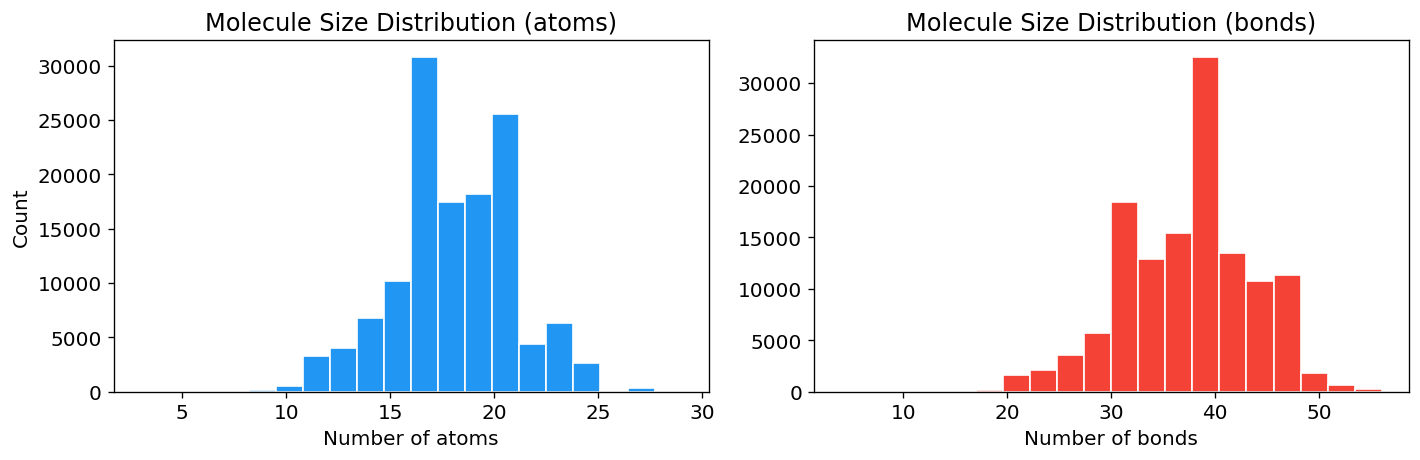

Mean atoms : 18.0  |  Max: 29
Mean bonds : 37.3  |  Max: 56


In [4]:
num_nodes = [dataset[i].num_nodes for i in range(len(dataset))]
num_edges = [dataset[i].num_edges for i in range(len(dataset))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(num_nodes, bins=20, color='#2196F3', edgecolor='white')
axes[0].set_xlabel('Number of atoms')
axes[0].set_ylabel('Count')
axes[0].set_title('Molecule Size Distribution (atoms)')

axes[1].hist(num_edges, bins=20, color='#F44336', edgecolor='white')
axes[1].set_xlabel('Number of bonds')
axes[1].set_title('Molecule Size Distribution (bonds)')

plt.tight_layout()
plt.savefig('../results/figures/dataset_size_distribution.pdf', bbox_inches='tight')
plt.show()

print(f'Mean atoms : {np.mean(num_nodes):.1f}  |  Max: {max(num_nodes)}')
print(f'Mean bonds : {np.mean(num_edges):.1f}  |  Max: {max(num_edges)}')

## 3. Target Property Distribution (μ — Dipole Moment)

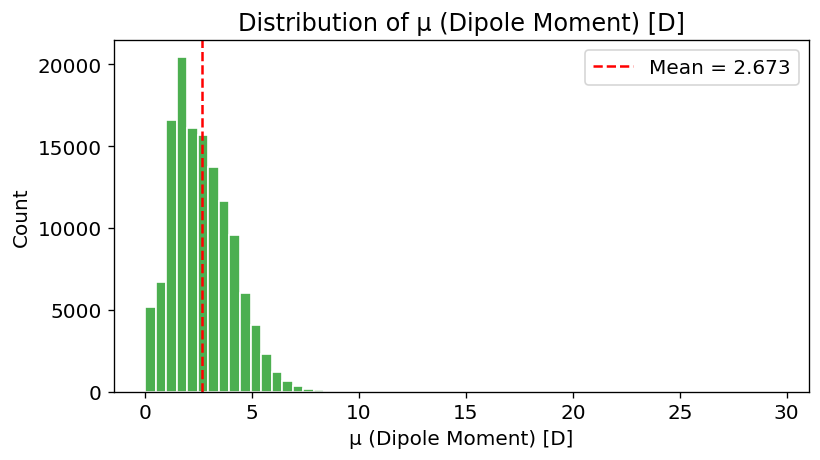

Mean  : 2.6730
Std   : 1.5035
Min   : 0.0000
Max   : 29.5564


In [5]:
TARGET_IDX = 0   # mu (dipole moment)
TARGET_NAME = 'μ (Dipole Moment) [D]'

targets = torch.stack([dataset[i].y[0, TARGET_IDX] for i in range(len(dataset))])

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(targets.numpy(), bins=60, color='#4CAF50', edgecolor='white')
ax.set_xlabel(TARGET_NAME)
ax.set_ylabel('Count')
ax.set_title(f'Distribution of {TARGET_NAME}')
ax.axvline(targets.mean().item(), color='red', linestyle='--',
           label=f'Mean = {targets.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/target_distribution.pdf', bbox_inches='tight')
plt.show()

print(f'Mean  : {targets.mean():.4f}')
print(f'Std   : {targets.std():.4f}')
print(f'Min   : {targets.min():.4f}')
print(f'Max   : {targets.max():.4f}')

## 4. Atom Type Distribution

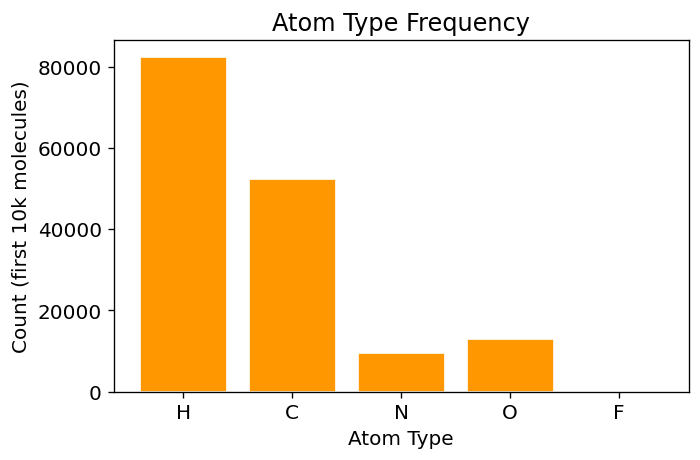

In [6]:
from src.data.featurizer import ATOM_FEATURE_NAMES

# Collect all node feature vectors
all_x = torch.cat([dataset[i].x for i in range(min(10000, len(dataset)))], dim=0)

atom_counts = all_x[:, :5].sum(dim=0)  # first 5 dims = atom type one-hot
atom_labels = ['H', 'C', 'N', 'O', 'F']

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(atom_labels, atom_counts.numpy(), color='#FF9800', edgecolor='white')
ax.set_xlabel('Atom Type')
ax.set_ylabel('Count (first 10k molecules)')
ax.set_title('Atom Type Frequency')
plt.tight_layout()
plt.savefig('../results/figures/atom_distribution.pdf', bbox_inches='tight')
plt.show()

## 5. Baseline: Mean Predictor

In [7]:
# A trivial baseline: predict the training mean for every molecule
from src.data.dataset import QM9Dataset

cfg_dataset = {
    'root': '../data/QM9',
    'target_idx': 0,
    'target_name': 'mu',
    'target_unit': 'D',
    'split_sizes': [0.8, 0.1, 0.1],
    'seed': 42,
}

ds = QM9Dataset(cfg_dataset)
_, _, test_loader = ds.get_loaders(batch_size=256, num_workers=0)

all_targets = []
for batch in test_loader:
    all_targets.append(batch.y.squeeze(-1))
all_targets = torch.cat(all_targets)

mean_pred = torch.full_like(all_targets, ds.target_mean)
baseline_mae = (mean_pred - all_targets).abs().mean().item()

print(f'Mean-predictor baseline MAE: {baseline_mae:.4f} D')
print('(Our trained models should beat this by a significant margin)')

[Dataset] Loading QM9 from ../data/QM9 …


c:\Users\jga20\OneDrive - Universidad Pontificia Comillas\Master en IA\IA Geometrica\gnn3-molecular\notebooks\..\src\data\dataset.py:66: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  self.raw.data.y = self.raw.data.y[:, self.target_idx].unsqueeze(-1)


[Dataset] Target: mu (Dipole moment) [D]
[Dataset] Total molecules: 130831
[Dataset] Split: train=104664, val=13083, test=13084
[Dataset] Target normalization — mean=2.6746, std=1.5055


c:\Users\jga20\OneDrive - Universidad Pontificia Comillas\Master en IA\IA Geometrica\gnn3-molecular\notebooks\..\src\data\dataset.py:112: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_data, batch_size=batch_size,
c:\Users\jga20\OneDrive - Universidad Pontificia Comillas\Master en IA\IA Geometrica\gnn3-molecular\notebooks\..\src\data\dataset.py:116: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader   = DataLoader(val_data,   batch_size=batch_size,
c:\Users\jga20\OneDrive - Universidad Pontificia Comillas\Master en IA\IA Geometrica\gnn3-molecular\notebooks\..\src\data\dataset.py:120: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader  = DataLoader(test_data,  batch_size=batch_size,


Mean-predictor baseline MAE: 1.1808 D
(Our trained models should beat this by a significant margin)


## 6. Compare Results (after training)

            Model  MAE (D)  RMSE (D)
GRAPH_TRANSFORMER   0.3975    0.6149
              GIN   0.3998    0.6095
             MPNN   0.4500    0.6734
              GAT   0.4501    0.6501


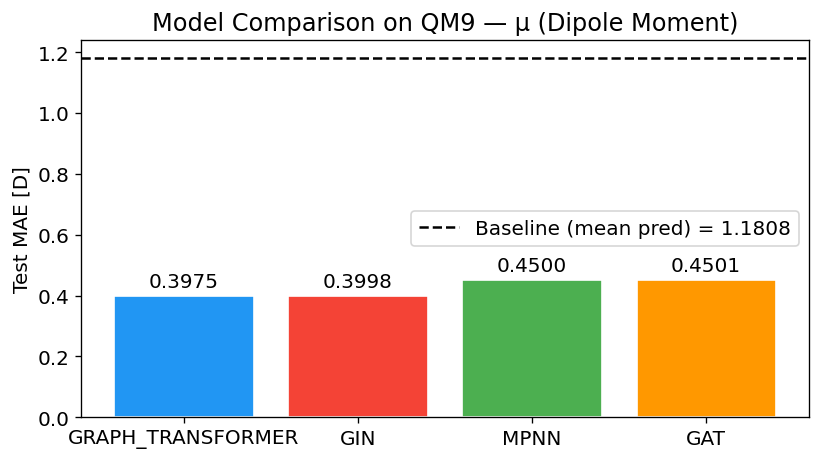

In [8]:
import json, glob

results = []
for path in glob.glob('../results/*/summary.json'):
    with open(path) as f:
        s = json.load(f)
    results.append({
        'Model': s['run_name'].split('_seed')[0].upper(),
        'MAE (D)': s['test_metrics']['mae'],
        'RMSE (D)': s['test_metrics']['rmse'],
    })

if results:
    df = pd.DataFrame(results).sort_values('MAE (D)')
    print(df.to_string(index=False))
    
    fig, ax = plt.subplots(figsize=(7, 4))
    colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']
    bars = ax.bar(df['Model'], df['MAE (D)'], color=colors[:len(df)], edgecolor='white')
    ax.bar_label(bars, fmt='%.4f', padding=3)
    ax.axhline(baseline_mae, color='black', linestyle='--',
               label=f'Baseline (mean pred) = {baseline_mae:.4f}')
    ax.set_ylabel('Test MAE [D]')
    ax.set_title('Model Comparison on QM9 — μ (Dipole Moment)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../results/figures/comparison_mae.pdf', bbox_inches='tight')
    plt.show()
else:
    print('No trained models found yet. Run scripts/run_all.sh first.')